# LeetCode #86: Partition List

https://leetcode.com/problems/partition-list/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Collect and rebuild | O(n) | O(n) | Two arrays for < x and >= x, then rebuild |
| **Two Dummy Heads ★** | **O(n)** | **O(1)** | Build two sublists in-place, merge at end |

---

## Understanding the Methods

### Brute Force (Arrays)
Scan list twice: first collect all nodes with val < x, then >= x. Rebuild. O(n) but O(n) extra space.

### Optimal: Two Dummy Heads ★
Create two dummy nodes: `loDummy` (nodes < x) and `hiDummy` (nodes >= x).
Walk curr through list; append each node to the appropriate sublist tail.
After traversal: hiTail.next = null (prevent cycle), loTail.next = hiDummy.next.
Return loDummy.next.

Key: setting hiTail.next = null is critical — curr.next from the last hi-node may still point into the middle of the original list.

**Constraints:**
* Number of nodes: [0, 200]
* Node values: [-100, 100]
* -200 <= x <= 200

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode Partition(ListNode head, int x) {
        var loDummy = new ListNode(0);
        var hiDummy = new ListNode(0);
        var lo = loDummy;
        var hi = hiDummy;
        var curr = head;

        while (curr != null) {
            if (curr.val < x) {
                lo.next = curr;
                lo = lo.next;
            } else {
                hi.next = curr;
                hi = hi.next;
            }
            curr = curr.next;
        }

        hi.next = null;          // terminate hi list (prevent cycle)
        lo.next = hiDummy.next;  // connect lo → hi
        return loDummy.next;
    }
}

### Python

In [ ]:
class Solution:
    def partition(self, head, x: int):
        lo_dummy = ListNode(0)
        hi_dummy = ListNode(0)
        lo = lo_dummy
        hi = hi_dummy
        curr = head

        while curr:
            if curr.val < x:
                lo.next = curr
                lo = lo.next
            else:
                hi.next = curr
                hi = hi.next
            curr = curr.next

        hi.next = None
        lo.next = hi_dummy.next
        return lo_dummy.next

### Go

In [ ]:
func partition(head *ListNode, x int) *ListNode {
    loDummy := &ListNode{}
    hiDummy := &ListNode{}
    lo := loDummy
    hi := hiDummy
    curr := head

    for curr != nil {
        if curr.Val < x {
            lo.Next = curr
            lo = lo.Next
        } else {
            hi.Next = curr
            hi = hi.Next
        }
        curr = curr.Next
    }

    hi.Next = nil
    lo.Next = hiDummy.Next
    return loDummy.Next
}

### Rust

In [ ]:
impl Solution {
    pub fn partition(head: Option<Box<ListNode>>, x: i32) -> Option<Box<ListNode>> {
        let mut lo_dummy = Box::new(ListNode::new(0));
        let mut hi_dummy = Box::new(ListNode::new(0));
        let mut lo = &mut lo_dummy as *mut Box<ListNode>;
        let mut hi = &mut hi_dummy as *mut Box<ListNode>;
        let mut curr = head;

        while let Some(mut node) = curr {
            curr = node.next.take();
            if node.val < x {
                unsafe {
                    (*lo).next = Some(node);
                    lo = (*lo).next.as_mut().unwrap() as *mut Box<ListNode>;
                }
            } else {
                unsafe {
                    (*hi).next = Some(node);
                    hi = (*hi).next.as_mut().unwrap() as *mut Box<ListNode>;
                }
            }
        }

        unsafe {
            (*hi).next = None;
            (*lo).next = hi_dummy.next.take();
        }
        lo_dummy.next
    }
}

## Example Scenarios

### 1. Common Case — Standard Partition
**Input:** `head = [1, 4, 3, 2, 5, 2]`, `x = 3`

Walk each node: 1<3 → lo, 4≥3 → hi, 3≥3 → hi, 2<3 → lo, 5≥3 → hi, 2<3 → lo. Stitch lo-tail.next = hi-head.

*Why tricky:* Interleaved < and ≥ values verify relative order is preserved within each partition group.

$n = 6$ nodes, $O(n)$ time, $O(1)$ space (two dummy pointers only).

**Output:** `1 → 2 → 2 → 4 → 3 → 5`

---

### 2. Slightly Complex — Negative Values & x = 0
**Input:** `head = [-3, 5, -1, 0, 4, -2]`, `x = 0`

Partition around zero: -3<0 → lo, 5≥0 → hi, -1<0 → lo, 0≥0 → hi, 4≥0 → hi, -2<0 → lo. Note that 0 itself goes to hi (≥ x).

*Why tricky:* Negative values and $x = 0$ boundary test signed comparisons. Zero lands in the hi group, not lo.

$n = 6$. lo gets 3 nodes, hi gets 3 nodes. Total comparisons $= 6$.

**Output:** `-3 → -1 → -2 → 5 → 0 → 4`

---

### 3. Edge Case: Time Factor — 200 Nodes, All < x
**Input:** `head = [100, 100, ..., -100]` (200 nodes), `x = 101`

All 200 node values are $\leq 100 < 101$, so every node routes to lo. The hi-list stays empty. Full scan of all $n = 200$ nodes required — no early exit.

*Why tricky:* Worst-case time with max $n = 200$ (constraint limit). Must correctly set `hi.next = null` even on an empty hi-list.

$T(n) = O(200)$. All nodes in lo; hi.next remains null. $O(1)$ space.

**Output:** identical to input (all 200 nodes, original order)

---

### 4. Edge Case: Space Factor — All Nodes ≥ x
**Input:** `head = [5, 6, 7, 8, 9, 10]`, `x = -200`

$x = -200$ (minimum allowed). Every node value $\geq -200$, so all go to hi. The lo-list stays empty. Return `loDummy.next = hiDummy.next`.

*Why tricky:* All nodes in one partition tests the empty lo-list connecting correctly to hi-head without null dereference.

lo: 0 nodes, hi: 6 nodes. $O(1)$ extra space (just dummy nodes).

**Output:** `5 → 6 → 7 → 8 → 9 → 10` (unchanged)

---

### 5. Almost-Impossible but Plausible — Boundary Values & Cycle Prevention
**Input:** `head = [100, -100, 100, -100, 99]`, `x = 100`

100≥100 → hi; -100<100 → lo; 100≥100 → hi; -100<100 → lo; 99<100 → lo. Without `hi.next = null`, the last hi-node (2nd 100) still has `.next` pointing to -100, creating an infinite cycle!

*Why tricky:* Extreme boundary values $(-100, 100)$ with interleaving means `hiTail.next` was originally pointing into lo-portion. Forgetting `hi.next = null` causes infinite traversal.

Critical step: `hi.next = null` breaks the stale pointer from node(100) $\to$ node(-100).

**Output:** `-100 → -100 → 99 → 100 → 100`

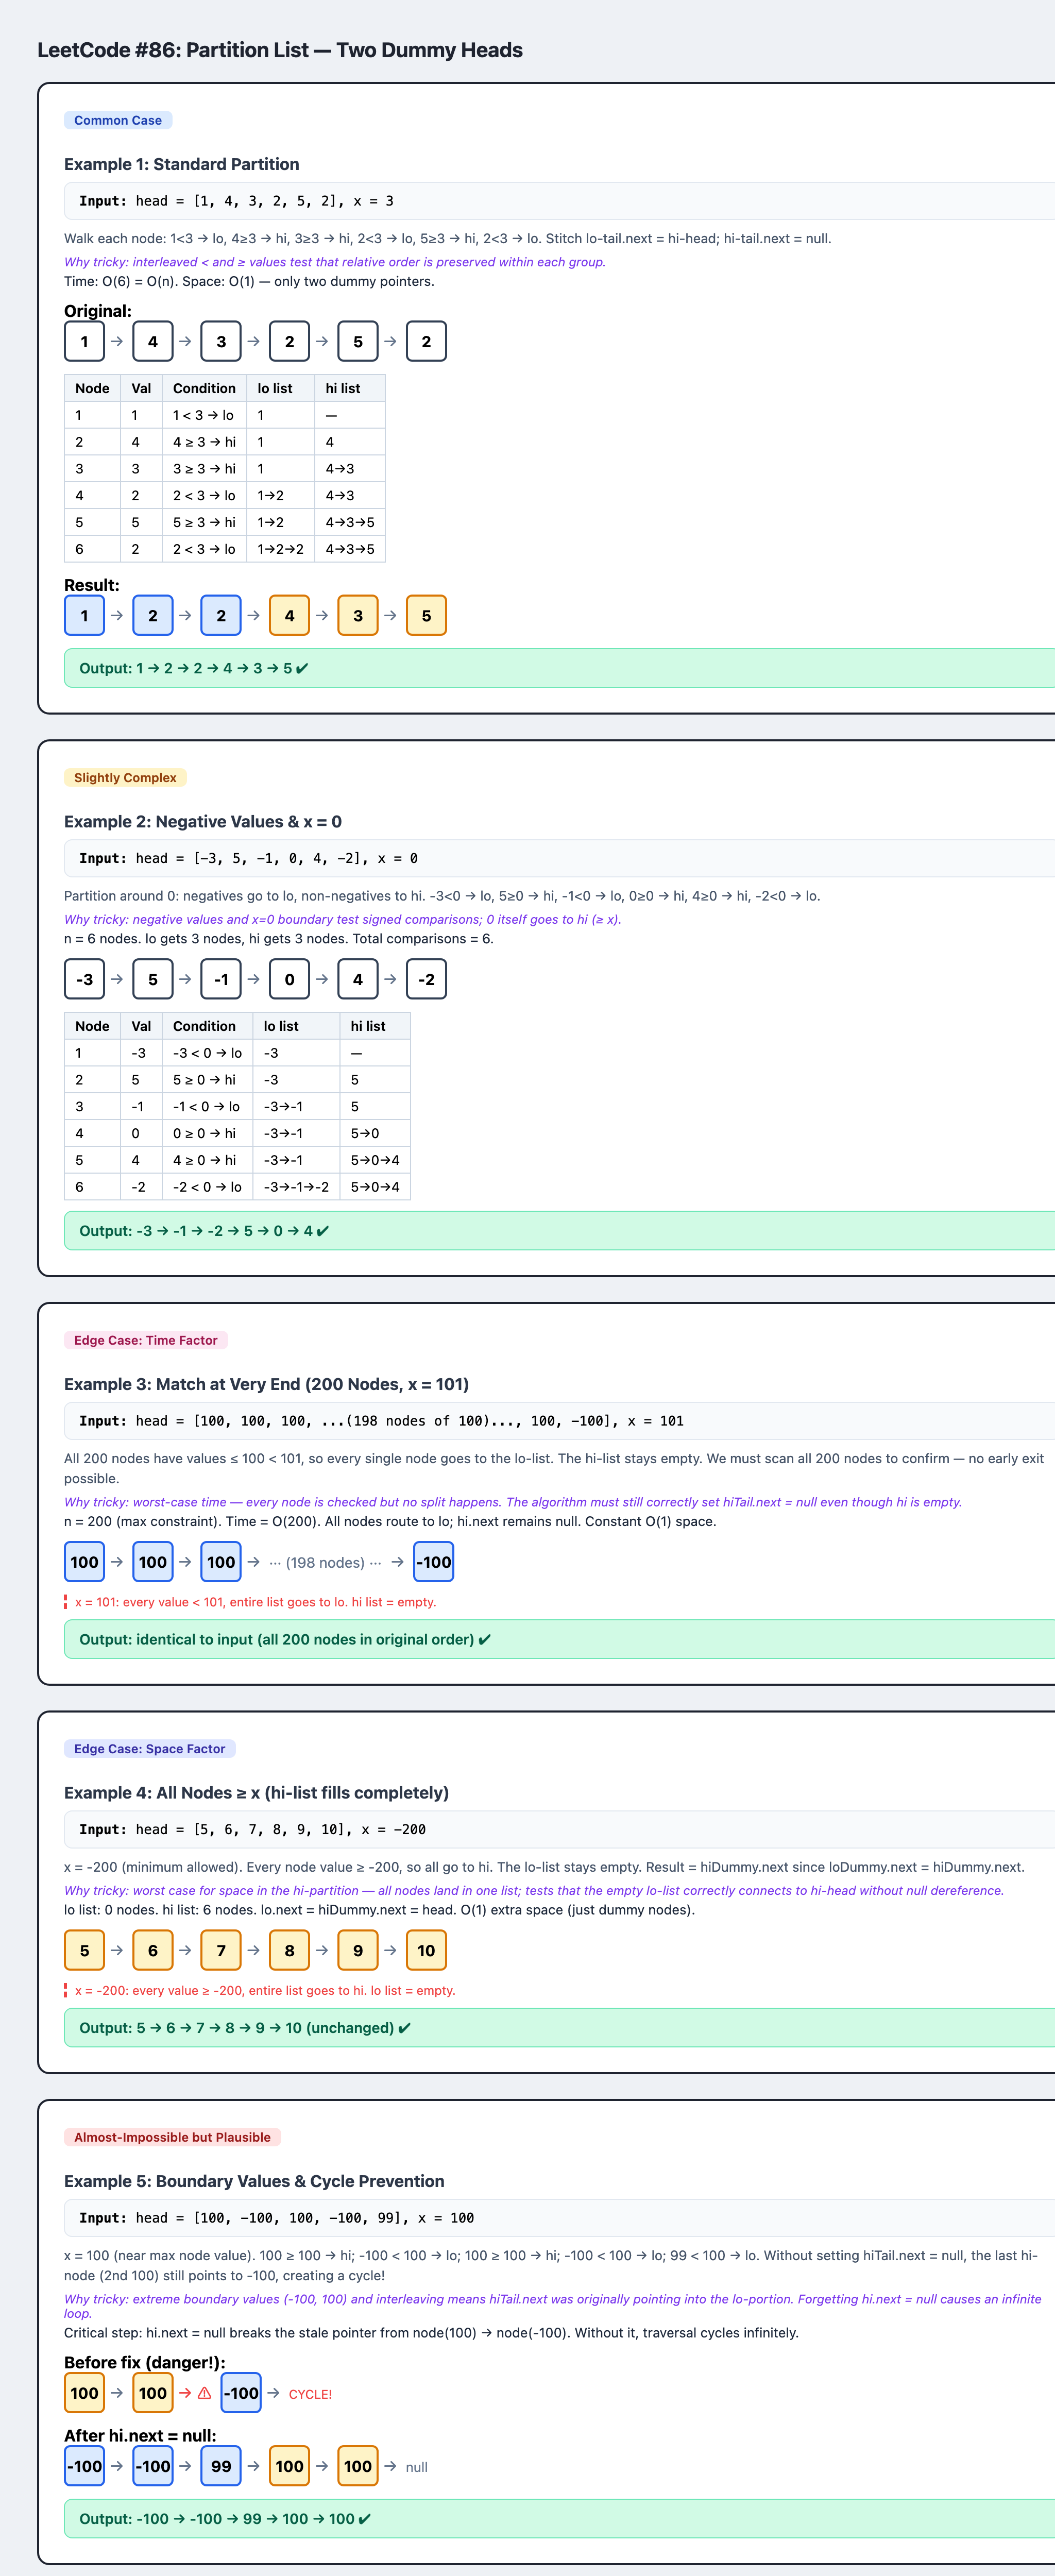